# Phase 1 — Data Collection, Cleaning & Merging
**Project:** Forecasting the Recovery of Global Economies from Shocks through Time Series Modeling

**Datasets:**
1. GDP per capita (Our World in Data)
2. Population Total (World Bank WDI)
3. Global Inflation — Headline CPI Annual (World Bank)
4. Age Dependency Ratio (World Bank WDI)
5. Employment Rate (Our World in Data)
6. Real Interest Rates (World Bank WDI)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries imported successfully')

Libraries imported successfully


## 2. Define File Paths

In [2]:
DATA_DIR = r'..\data'

PATHS = {
    'gdp':        os.path.join(DATA_DIR, 'gdp-per-capita-worldbank', 'gdp-per-capita-worldbank.csv'),
    'population': os.path.join(DATA_DIR, 'API_SP.POP.TOTL_DS2_en_csv_v2_58', 'API_SP.POP.TOTL_DS2_en_csv_v2_58.csv'),
    'inflation':  os.path.join(DATA_DIR, 'Inflation-data', 'hcpi_a.dta'),
    'dependency': os.path.join(DATA_DIR, 'age_dependency_ratio', 'API_SP.POP.DPND_DS2_en_csv_v2_3188.csv'),
    'employment': os.path.join(DATA_DIR, 'employment-to-population-ratio', 'employment-to-population-ratio.csv'),
    'interest':   os.path.join(DATA_DIR, 'P_Real interest rates', '3b20a2a3-9edb-4f88-b764-2f061e29a419_Data.csv'),
}

OUTPUT_PATH = r'..\output\master_dataset.csv'

for name, path in PATHS.items():
    status = 'FOUND' if os.path.exists(path) else 'MISSING'
    print(f'{name:12s}: {status}')

gdp         : FOUND
population  : FOUND
inflation   : FOUND
dependency  : FOUND
employment  : FOUND
interest    : FOUND


## 3. Load & Clean Each Dataset

### 3.1 GDP per Capita
- Source: Our World in Data
- Format: Long CSV — columns: Entity, Code, Year, GDP per capita, World region

In [3]:
gdp_raw = pd.read_csv(PATHS['gdp'])
print('Raw shape:', gdp_raw.shape)
gdp_raw.head(3)

Raw shape: (7240, 5)


,Entity,Code,Year,GDP per capita,World region according to OWID
0,Afghanistan,AFG,2000,1617.83,Asia
1,Afghanistan,AFG,2001,1454.11,Asia
2,Afghanistan,AFG,2002,1774.31,Asia


In [4]:
gdp = gdp_raw[['Code', 'Year', 'GDP per capita']].copy()
gdp.columns = ['country_code', 'year', 'gdp_per_capita']
gdp = gdp.dropna(subset=['country_code', 'year', 'gdp_per_capita'])
gdp['year'] = gdp['year'].astype(int)

print('Shape:', gdp.shape)
print('Years:', gdp['year'].min(), '-', gdp['year'].max())
print('Countries:', gdp['country_code'].nunique())
print('Missing:', gdp.isnull().sum().to_dict())
gdp.head(3)

Shape: (7240, 3)
Years: 1990 - 2024
Countries: 212
Missing: {'country_code': 0, 'year': 0, 'gdp_per_capita': 0}


,country_code,year,gdp_per_capita
0,AFG,2000,1617.83
1,AFG,2001,1454.11
2,AFG,2002,1774.31


### 3.2 Population Total
- Source: World Bank WDI
- Format: Wide CSV (years as columns), first 4 rows are metadata — skip them

In [5]:
pop_raw = pd.read_csv(PATHS['population'], skiprows=4)
print('Raw shape:', pop_raw.shape)
pop_raw.head(2)

Raw shape: (266, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.00,55578.00,56320.00,57002.00,57619.00,58190.00,58694.00,58990.00,59069.00,59052.00,58950.00,58781.00,58047.00,58299.00,58349.00,58295.00,58368.00,58580.00,58776.00,59191.00,59909.00,...,92074.00,93128.00,95138.00,97635.00,99405.00,100150.00,100917.00,101604.00,101838.00,102591.00,104110.00,105675.00,106807.00,107906.00,108727.00,108735.00,108908.00,109203.00,108587.00,107700.00,107310.00,107359.00,107995.00,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.00,133534923.00,137171659.00,140945536.00,144904094.00,149033472.00,153281203.00,157704381.00,162329396.00,167088245.00,171984985.00,177022314.00,182126556.00,187524135.00,193186642.00,198914573.00,204802976.00,210680842.00,217074286.00,223974122.00,230792729.00,...,427820358.00,439173286.00,450928044.00,463076637.00,475606210.00,488580707.00,502070763.00,516003448.00,530308387.00,544737983.00,559609961.00,575202699.00,590968990.00,607123269.00,623369401.00,640058741.00,657801085.00,675950189.00,694446100.00,713090928.00,731821393.00,750491370.00,769280888.00,NaN,NaN


In [6]:
pop_wide = pop_raw.drop(columns=['Country Name', 'Indicator Name', 'Indicator Code'], errors='ignore')
pop_wide = pop_wide.dropna(subset=['Country Code'])
pop_wide = pop_wide.dropna(axis=1, how='all')  # remove fully empty columns

pop = pop_wide.melt(id_vars=['Country Code'], var_name='year', value_name='population')
pop.columns = ['country_code', 'year', 'population']
pop['year'] = pd.to_numeric(pop['year'], errors='coerce')
pop['population'] = pd.to_numeric(pop['population'], errors='coerce')
pop = pop.dropna(subset=['year', 'population'])
pop['year'] = pop['year'].astype(int)

print('Shape:', pop.shape)
print('Years:', pop['year'].min(), '-', pop['year'].max())
print('Countries:', pop['country_code'].nunique())
pop.head(3)

Shape: (17195, 3)
Years: 1960 - 2024
Countries: 265


,country_code,year,population
0,ABW,1960,54922.00
1,AFE,1960,130075728.00
2,AFG,1960,9035043.00


### 3.3 Inflation — Headline CPI Annual
- Source: World Bank Global Inflation Database
- Format: Stata .dta file
- Columns: CountryCode, IMFCountryCode, Country, _1970, _1971, ..., _2024

In [7]:
inf_raw = pd.read_stata(PATHS['inflation'])
print('Raw shape:', inf_raw.shape)
print('Columns:', inf_raw.columns.tolist())
inf_raw.head(3)

Raw shape: (207, 58)
Columns: ['CountryCode', 'IMFCountryCode', 'Country', '_1970', '_1971', '_1972', '_1973', '_1974', '_1975', '_1976', '_1977', '_1978', '_1979', '_1980', '_1981', '_1982', '_1983', '_1984', '_1985', '_1986', '_1987', '_1988', '_1989', '_1990', '_1991', '_1992', '_1993', '_1994', '_1995', '_1996', '_1997', '_1998', '_1999', '_2000', '_2001', '_2002', '_2003', '_2004', '_2005', '_2006', '_2007', '_2008', '_2009', '_2010', '_2011', '_2012', '_2013', '_2014', '_2015', '_2016', '_2017', '_2018', '_2019', '_2020', '_2021', '_2022', '_2023', '_2024']


,CountryCode,IMFCountryCode,Country,_1970,_1971,_1972,_1973,_1974,_1975,_1976,_1977,_1978,_1979,_1980,_1981,_1982,_1983,_1984,_1985,_1986,_1987,_1988,_1989,_1990,_1991,...,_2000,_2001,_2002,_2003,_2004,_2005,_2006,_2007,_2008,_2009,_2010,_2011,_2012,_2013,_2014,_2015,_2016,_2017,_2018,_2019,_2020,_2021,_2022,_2023,_2024
0,ABW,314.00,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.05,2.89,3.32,3.66,2.53,3.40,3.61,5.39,8.96,-2.14,2.08,4.32,0.63,-2.37,0.42,0.48,-0.89,-0.47,3.58,4.26,1.22,0.74,5.52,3.36,1.71
1,AFG,512.00,Afghanistan,25.51,25.51,-12.52,-10.68,10.23,11.85,0.60,7.65,5.00,9.90,13.40,22.20,18.20,15.90,20.40,8.70,-2.10,18.40,27.50,71.50,47.40,43.80,...,0.00,-43.40,51.93,35.66,16.36,10.57,6.78,8.68,26.42,-6.81,2.18,11.80,6.44,7.39,4.67,-0.66,4.38,4.98,0.63,2.30,5.44,5.06,10.60,-7.71,-6.60
2,AGO,614.00,Angola,7.97,5.78,15.80,15.67,27.42,29.00,80.70,69.01,48.46,101.30,46.71,1.39,1.83,1.83,1.83,1.83,1.83,1.83,1.83,1.83,1.83,85.26,...,325.03,152.59,108.89,98.22,43.53,22.96,13.31,12.25,12.47,13.72,14.48,13.48,10.28,8.78,7.30,9.16,32.38,29.84,19.63,17.08,21.02,23.85,23.83,13.64,28.24


In [8]:
# Year columns are named _1970, _1971, ..., _2024
id_cols_inf = ['CountryCode', 'IMFCountryCode', 'Country']
year_cols_inf = [c for c in inf_raw.columns if c.startswith('_') and c[1:].isdigit()]
print('Year columns:', year_cols_inf[:5], '...', year_cols_inf[-5:])

# Melt to long format
inf = inf_raw[id_cols_inf + year_cols_inf].melt(
    id_vars=id_cols_inf, var_name='year', value_name='inflation_hcpi'
)

# Clean year: '_1970' -> 1970
inf['year'] = inf['year'].str.replace('_', '', regex=False)
inf['year'] = pd.to_numeric(inf['year'], errors='coerce')
inf['inflation_hcpi'] = pd.to_numeric(inf['inflation_hcpi'], errors='coerce')
inf = inf.dropna(subset=['year', 'inflation_hcpi'])
inf['year'] = inf['year'].astype(int)

# Rename country code column
inf = inf.rename(columns={'CountryCode': 'country_code'})
inf = inf[['country_code', 'year', 'inflation_hcpi']].copy()
inf = inf.dropna(subset=['country_code'])

print('Shape:', inf.shape)
print('Years:', inf['year'].min(), '-', inf['year'].max())
print('Countries:', inf['country_code'].nunique())
inf.head(3)

Year columns: ['_1970', '_1971', '_1972', '_1973', '_1974'] ... ['_2020', '_2021', '_2022', '_2023', '_2024']
Shape: (9912, 3)
Years: 1970 - 2024
Countries: 202


,country_code,year,inflation_hcpi
1,AFG,1970,25.51
2,AGO,1970,7.97
4,ARE,1970,21.98


### 3.4 Age Dependency Ratio
- Source: World Bank WDI
- Format: Wide CSV (same structure as Population dataset)

In [9]:
dep_raw = pd.read_csv(PATHS['dependency'], skiprows=4)
print('Raw shape:', dep_raw.shape)
dep_raw.head(2)

Raw shape: (266, 71)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Age dependency ratio (% of working-age populat...,SP.POP.DPND,83.05,81.97,81.06,79.79,78.15,76.35,74.59,73.47,73.02,72.64,72.19,71.51,69.81,67.27,64.77,62.37,60.03,57.91,56.16,54.70,53.62,...,43.08,42.88,42.69,42.64,42.77,42.99,43.26,43.54,43.45,43.05,42.86,43.04,43.52,44.25,45.16,46.13,47.12,48.10,48.88,49.32,49.80,50.50,51.29,NaN,NaN
1,Africa Eastern and Southern,AFE,Age dependency ratio (% of working-age populat...,SP.POP.DPND,88.97,89.32,89.69,90.12,90.55,91.01,91.54,92.05,92.52,92.96,93.43,93.95,94.47,94.92,95.21,95.38,95.59,95.76,95.78,95.81,95.78,...,91.53,91.14,90.77,90.45,90.16,89.83,89.46,89.05,88.57,87.98,87.36,86.74,86.09,85.38,84.65,83.88,83.03,82.24,81.43,80.63,79.88,79.15,78.44,NaN,NaN


In [10]:
dep_wide = dep_raw.drop(columns=['Country Name', 'Indicator Name', 'Indicator Code'], errors='ignore')
dep_wide = dep_wide.dropna(subset=['Country Code'])
dep_wide = dep_wide.dropna(axis=1, how='all')

dep = dep_wide.melt(id_vars=['Country Code'], var_name='year', value_name='dependency_ratio')
dep.columns = ['country_code', 'year', 'dependency_ratio']
dep['year'] = pd.to_numeric(dep['year'], errors='coerce')
dep['dependency_ratio'] = pd.to_numeric(dep['dependency_ratio'], errors='coerce')
dep = dep.dropna(subset=['year', 'dependency_ratio'])
dep['year'] = dep['year'].astype(int)

print('Shape:', dep.shape)
print('Years:', dep['year'].min(), '-', dep['year'].max())
print('Countries:', dep['country_code'].nunique())
dep.head(3)

Shape: (17195, 3)
Years: 1960 - 2024
Countries: 265


,country_code,year,dependency_ratio
0,ABW,1960,83.05
1,AFE,1960,88.97
2,AFG,1960,81.06


### 3.5 Employment Rate
- Source: Our World in Data
- Format: Long CSV — columns: Entity, Code, Year, Employment rate

In [11]:
emp_raw = pd.read_csv(PATHS['employment'])
print('Raw shape:', emp_raw.shape)
emp_raw.head(3)

Raw shape: (6986, 4)


,Entity,Code,Year,Employment rate
0,Afghanistan,AFG,1991,43.38
1,Afghanistan,AFG,1992,43.34
2,Afghanistan,AFG,1993,43.30


In [12]:
emp = emp_raw[['Code', 'Year', 'Employment rate']].copy()
emp.columns = ['country_code', 'year', 'employment_rate']
emp = emp.dropna(subset=['country_code', 'year', 'employment_rate'])
emp['year'] = emp['year'].astype(int)

print('Shape:', emp.shape)
print('Years:', emp['year'].min(), '-', emp['year'].max())
print('Countries:', emp['country_code'].nunique())
emp.head(3)

Shape: (6986, 3)
Years: 1991 - 2025
Countries: 200


,country_code,year,employment_rate
0,AFG,1991,43.38
1,AFG,1992,43.34
2,AFG,1993,43.30


### 3.6 Real Interest Rates
- Source: World Bank WDI
- Format: Wide CSV — year columns have format '1970 [YR1970]'
- Missing values are coded as '..'

In [13]:
int_raw = pd.read_csv(PATHS['interest'])
print('Raw shape:', int_raw.shape)
int_raw.head(3)

Raw shape: (251, 49)


,Series Name,Series Code,Country Name,Country Code,1970 [YR1970],1971 [YR1971],1972 [YR1972],1973 [YR1973],1974 [YR1974],1975 [YR1975],1976 [YR1976],1977 [YR1977],1978 [YR1978],1979 [YR1979],1980 [YR1980],1981 [YR1981],1982 [YR1982],1983 [YR1983],1984 [YR1984],1985 [YR1985],1986 [YR1986],1987 [YR1987],1988 [YR1988],1989 [YR1989],1990 [YR1990],1991 [YR1991],1992 [YR1992],1993 [YR1993],1994 [YR1994],1995 [YR1995],1996 [YR1996],1997 [YR1997],1998 [YR1998],1999 [YR1999],2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014]
0,Real interest rate (%),FR.INR.RINR,Argentina,ARG,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,-8.56602872006595,-7.77340523607891,-6.74819555440488,-5.48583918237907,-11.6006987702162
1,Real interest rate (%),FR.INR.RINR,Croatia,HRV,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,-1.47953164033389,-41.9571288924379,-2.64234672097419,17.9907431046096,8.02411181933112,7.000457316528,11.0427695750227,7.40046327315708,5.10522770527876,8.66644271414854,6.97616215059997,7.8370724525506,7.83280455960883,5.82832254833918,4.83706670295624,4.30201649125526,8.32314888806859,9.37036526291186,7.8823305094704,7.95701684150427,8.44680311573686,8.44053899838005
2,Real interest rate (%),FR.INR.RINR,Estonia,EST,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..,..


In [14]:
int_wide = int_raw[['Country Code'] + [c for c in int_raw.columns if '[YR' in str(c)]].copy()
int_wide = int_wide.dropna(subset=['Country Code'])

# Melt to long
int_long = int_wide.melt(id_vars=['Country Code'], var_name='year_label', value_name='interest_rate')

# Extract year from '1970 [YR1970]' -> 1970
int_long['year'] = int_long['year_label'].str.extract(r'(\d{4})').astype(float)
int_long = int_long.drop(columns=['year_label'])
int_long.columns = ['country_code', 'interest_rate', 'year']

# Replace '..' (World Bank missing code) with NaN
int_long['interest_rate'] = int_long['interest_rate'].replace('..', np.nan)
int_long['interest_rate'] = pd.to_numeric(int_long['interest_rate'], errors='coerce')
int_long = int_long.dropna(subset=['year', 'interest_rate'])
int_long['year'] = int_long['year'].astype(int)
int_long = int_long[['country_code', 'year', 'interest_rate']]

print('Shape:', int_long.shape)
print('Years:', int_long['year'].min(), '-', int_long['year'].max())
print('Countries:', int_long['country_code'].nunique())
int_long.head(3)

Shape: (3517, 3)
Years: 1970 - 2014
Countries: 148


,country_code,year,interest_rate
8,MYS,1970,9.76
15,USA,1970,2.51
16,GBR,1970,-1.83


## 4. Merge All Datasets
Base: GDP (primary indicator). All others left-joined on country_code + year.

In [15]:
master = gdp.copy()

datasets = [
    (pop,      'population'),
    (inf,      'inflation'),
    (dep,      'dependency'),
    (emp,      'employment'),
    (int_long, 'interest'),
]

for df, name in datasets:
    master = master.merge(df, on=['country_code', 'year'], how='left')
    print(f'Merged {name:12s} -> {master.shape}')

print('\nFinal master shape:', master.shape)
master.head(3)

Merged population   -> (7240, 4)
Merged inflation    -> (7240, 5)
Merged dependency   -> (7240, 6)
Merged employment   -> (7240, 7)
Merged interest     -> (7240, 8)

Final master shape: (7240, 8)


,country_code,year,gdp_per_capita,population,inflation_hcpi,dependency_ratio,employment_rate,interest_rate
0,AFG,2000,1617.83,20130327.00,0.00,109.59,42.88,NaN
1,AFG,2001,1454.11,20284307.00,-43.40,110.22,42.82,NaN
2,AFG,2002,1774.31,21378117.00,51.93,110.53,42.85,NaN


## 5. Missing Value Analysis

In [16]:
missing_pct = (master.isnull().sum() / len(master) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': master.isnull().sum(),
    'Missing %': missing_pct
})
print('Missing Value Summary:')
print(missing_df)

Missing Value Summary:
                  Missing Count  Missing %
country_code                  0       0.00
year                          0       0.00
gdp_per_capita                0       0.00
population                  472       6.52
inflation_hcpi              808      11.16
dependency_ratio            472       6.52
employment_rate             850      11.74
interest_rate              4454      61.52


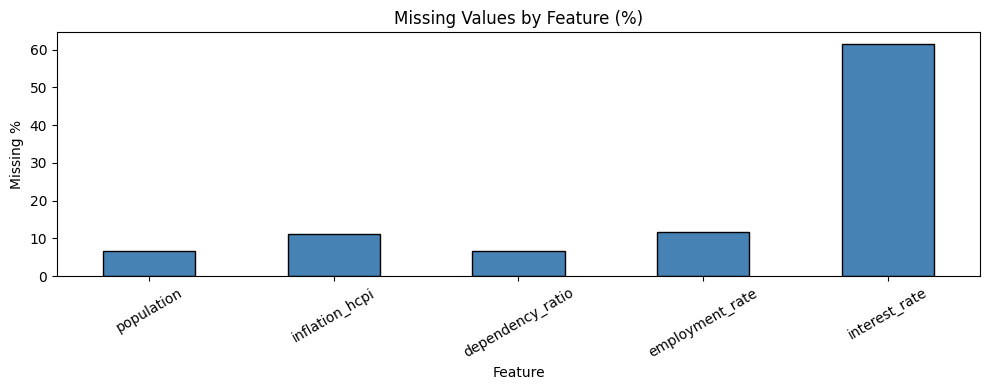

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct[missing_pct > 0].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Missing Values by Feature (%)')
ax.set_ylabel('Missing %')
ax.set_xlabel('Feature')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(r'..\output\missing_values.png', dpi=150)
plt.show()

## 6. Handle Missing Values
Strategy: Forward-fill then backward-fill within each country (appropriate for time series).

In [18]:
# ── Missing Value Handling (3-step, time-valid strategy) ────────────────────
# Step 1: ffill  — carry last known value forward (past → future, no leakage)
# Step 2: interpolate — linear fill for small leading gaps (≤3 yrs) at series start
# Step 3: median  — per-country median as last resort (no time dependency)
# NOTE: bfill is intentionally excluded — it would fill past rows with future values,
#       introducing temporal data leakage in time-series training data.

fill_cols = ['population', 'inflation_hcpi', 'dependency_ratio', 'employment_rate', 'interest_rate']

master = master.sort_values(['country_code', 'year'])

for col in fill_cols:
    if col in master.columns:
        master[col] = master.groupby('country_code')[col].transform(
            lambda x: (
                x.ffill()                                      # Step 1: forward fill
                 .interpolate(method='linear', limit=3,        # Step 2: linear interpolation
                              limit_direction='forward')        #         for leading gaps only
                 .fillna(x.median())                           # Step 3: per-country median
            )
        )

print('Missing after 3-step fill:')
print(master.isnull().sum())
print('\nNote: Any remaining NaNs are in gdp_per_capita (primary target — never imputed).')

Missing after 3-step fill:
country_code           0
year                   0
gdp_per_capita         0
population           472
inflation_hcpi       664
dependency_ratio     472
employment_rate      660
interest_rate       2273
dtype: int64

Note: Any remaining NaNs are in gdp_per_capita (primary target — never imputed).


In [19]:
# Drop rows still missing GDP — cannot impute the primary target variable
before = len(master)
master = master.dropna(subset=['gdp_per_capita'])
print(f'Dropped {before - len(master)} rows with missing GDP. Remaining: {len(master)}')

Dropped 0 rows with missing GDP. Remaining: 7240


## 7. Master Dataset Overview

In [20]:
print('=' * 50)
print('MASTER DATASET SUMMARY')
print('=' * 50)
print(f'Shape      : {master.shape}')
print(f'Countries  : {master["country_code"].nunique()}')
print(f'Year Range : {master["year"].min()} - {master["year"].max()}')
print(f'Columns    : {master.columns.tolist()}')
print()
master.describe()

MASTER DATASET SUMMARY
Shape      : (7240, 8)
Countries  : 212
Year Range : 1990 - 2024
Columns    : ['country_code', 'year', 'gdp_per_capita', 'population', 'inflation_hcpi', 'dependency_ratio', 'employment_rate', 'interest_rate']



,year,gdp_per_capita,population,inflation_hcpi,dependency_ratio,employment_rate,interest_rate
count,7240.00,7240.00,6768.00,6576.00,6768.00,6580.00,4967.00
mean,2007.20,21842.84,34208785.87,34.02,62.95,56.61,6.30
std,10.06,23830.95,131394928.45,458.86,19.13,11.66,10.84
min,1990.00,510.82,8798.00,-72.73,17.30,19.84,-97.69
25%,1999.00,4520.73,1269636.25,1.86,48.57,49.68,2.62
50%,2007.00,12714.60,6224743.50,4.02,57.06,56.74,6.04
75%,2016.00,32586.05,21214637.50,8.57,78.11,63.44,9.82
max,2024.00,174569.52,1450935791.00,23773.10,118.45,87.46,139.96


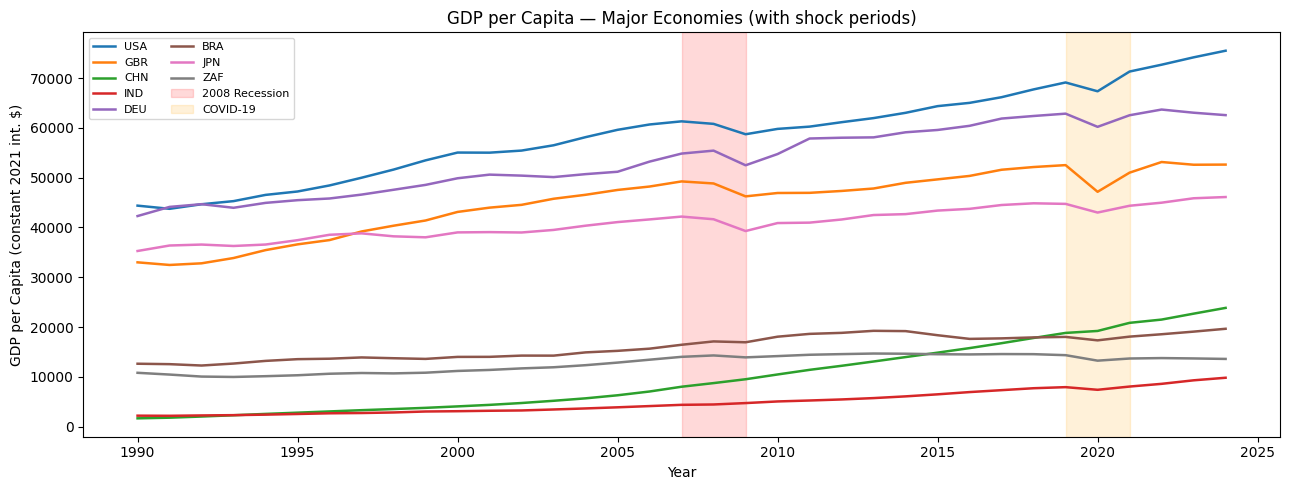

In [21]:
# GDP trend for major economies with shock periods highlighted
sample_countries = ['USA', 'GBR', 'CHN', 'IND', 'DEU', 'BRA', 'JPN', 'ZAF']
sample = master[master['country_code'].isin(sample_countries)]

plt.figure(figsize=(13, 5))
for country in sample_countries:
    data = sample[sample['country_code'] == country]
    if len(data) > 0:
        plt.plot(data['year'], data['gdp_per_capita'], label=country, linewidth=1.8)

plt.axvspan(2007, 2009, alpha=0.15, color='red', label='2008 Recession')
plt.axvspan(2019, 2021, alpha=0.15, color='orange', label='COVID-19')

plt.title('GDP per Capita — Major Economies (with shock periods)')
plt.xlabel('Year')
plt.ylabel('GDP per Capita (constant 2021 int. $)')
plt.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(r'..\output\gdp_trends.png', dpi=150)
plt.show()

## 8. Save Master Dataset

In [22]:
master.to_csv(OUTPUT_PATH, index=False)
print(f'Saved to: {OUTPUT_PATH}')
print(f'Shape: {master.shape}')
master.head(10)

Saved to: ..\output\master_dataset.csv
Shape: (7240, 8)


,country_code,year,gdp_per_capita,population,inflation_hcpi,dependency_ratio,employment_rate,interest_rate
269,ABW,1990,33063.00,62753.00,2.89,48.39,NaN,4.57
270,ABW,1991,33993.21,65896.00,2.89,50.24,NaN,4.79
271,ABW,1992,34371.16,69005.00,2.89,51.04,NaN,6.53
272,ABW,1993,34540.34,73685.00,2.89,50.42,NaN,5.03
273,ABW,1994,35490.72,77595.00,2.89,49.79,NaN,4.06
274,ABW,1995,35386.86,79805.00,2.89,48.45,NaN,6.99
275,ABW,1996,34419.43,83021.00,3.20,46.67,NaN,6.89
276,ABW,1997,35444.58,86301.00,3.00,45.36,NaN,6.31
277,ABW,1998,35271.91,88451.00,1.88,44.39,NaN,4.17
278,ABW,1999,35227.48,89659.00,2.28,43.67,NaN,10.72


---
## Phase 1 Complete

| Step | Status |
|------|--------|
| Load 6 datasets | Done |
| Standardize to long format | Done |
| Handle missing values (ffill/bfill per country) | Done |
| Merge into master dataset | Done |
| Save to output/master_dataset.csv | Done |

**Next → Phase 2:** Feature Engineering & Shock Labeling